# Notebook 02 — Limpeza e preparação dos dados

**Objetivo:** transformar a amostra filtrada no notebook 01 em um dataset pronto para modelagem, aplicando os tratamentos identificados na inspeção inicial.

**Entrada:** `data/processed/df_filtrado_inspecao.csv` (18.191 respondentes)  
**Saída:** `data/processed/df_limpo.csv`

**Tratamentos aplicados:**
1. Conversão de `YearsCode` para numérico (tratamento de valores especiais)
2. Corte de outliers salariais (USD 1.000 a USD 500.000)
3. Criação da coluna auxiliar `log_salario` (apenas para modelo de robustez)
4. Redução de cardinalidade de `Country` (top 10 + "Outros")
5. Agrupamento de `DevType` em macro-categorias
6. Padronização de rótulos de `EdLevel`
7. Dummies das top 20 linguagens

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações visuais consistentes com notebook 01
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Caminhos
PASTA_DADOS = Path("../data/processed")
PASTA_FIGURAS = Path("../output/figures")
PASTA_TABELAS = Path("../output/tables")

## 1. Carregamento do dataset filtrado

Carrega o CSV produzido pelo notebook 01 e confirma dimensões e colunas.

In [2]:
df = pd.read_csv(PASTA_DADOS / "df_filtrado_inspecao.csv")

print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"\nColunas disponíveis:")
print(df.columns.tolist())
df.head()

Linhas: 18,191
Colunas: 9

Colunas disponíveis:
['ResponseId', 'MainBranch', 'EdLevel', 'Employment', 'YearsCode', 'DevType', 'Country', 'LanguageHaveWorkedWith', 'ConvertedCompYearly']


,ResponseId,MainBranch,EdLevel,Employment,YearsCode,DevType,Country,LanguageHaveWorkedWith,ConvertedCompYearly
0,1,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,14.0,"Developer, mobile",Ukraine,Bash/Shell (all shells);Dart;SQL,61256.0
1,2,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,10.0,"Developer, back-end",Netherlands,Java,104413.0
2,3,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",12.0,"Developer, front-end",Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,53061.0
3,4,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,5.0,"Developer, back-end",Ukraine,Java;Kotlin;SQL,36197.0
4,5,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",22.0,Engineering manager,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,60000.0


## 2. Diagnóstico consolidado

Antes de aplicar qualquer tratamento, confirma em uma única tela os problemas a serem resolvidos.

In [3]:
print("=" * 60)
print("DIAGNÓSTICO INICIAL")
print("=" * 60)

print(f"\n[1] YearsCode — tipo atual: {df['YearsCode'].dtype}")
print(f"    Valores nulos: {df['YearsCode'].isna().sum()}")

print(f"\n[2] ConvertedCompYearly — cauda longa?")
print(f"    Min: USD {df['ConvertedCompYearly'].min():,.0f}")
print(f"    Mediana: USD {df['ConvertedCompYearly'].median():,.0f}")
print(f"    Max: USD {df['ConvertedCompYearly'].max():,.0f}")

print(f"\n[3] Country — valores únicos: {df['Country'].nunique()}")
print(f"\n[4] DevType — valores únicos: {df['DevType'].nunique()}")
print(f"\n[5] EdLevel — valores únicos: {df['EdLevel'].nunique()}")

DIAGNÓSTICO INICIAL

[1] YearsCode — tipo atual: float64
    Valores nulos: 45

[2] ConvertedCompYearly — cauda longa?
    Min: USD 1
    Mediana: USD 80,254
    Max: USD 33,552,715

[3] Country — valores únicos: 153

[4] DevType — valores únicos: 32

[5] EdLevel — valores únicos: 8


## 3. Tratamento de YearsCode

A coluna foi carregada como `float64`. Verificamos se há valores especiais escondidos e tratamos os 45 nulos identificados no diagnóstico.

In [4]:
# Verifica valores únicos e range
print(f"Tipo: {df['YearsCode'].dtype}")
print(f"Nulos: {df['YearsCode'].isna().sum()}")
print(f"\nEstatísticas:")
print(df['YearsCode'].describe())
print(f"\nMenores valores: {sorted(df['YearsCode'].dropna().unique())[:5]}")
print(f"Maiores valores: {sorted(df['YearsCode'].dropna().unique())[-5:]}")

Tipo: float64
Nulos: 45

Estatísticas:
count    18146.000000
mean        18.197344
std         10.568806
min          1.000000
25%         10.000000
50%         15.000000
75%         25.000000
max        100.000000
Name: YearsCode, dtype: float64

Menores valores: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Maiores valores: [np.float64(58.0), np.float64(59.0), np.float64(60.0), np.float64(61.0), np.float64(100.0)]


In [5]:
mediana_years = df['YearsCode'].median()
n_acima_50 = (df['YearsCode'] > 50).sum()

df['YearsCode'] = df['YearsCode'].fillna(mediana_years).clip(upper=50)

print(f"Nulos preenchidos com mediana = {mediana_years}")
print(f"Valores acima de 50 anos ajustados: {n_acima_50}")
print(f"\nNovo resumo:")
print(df['YearsCode'].describe())

Nulos preenchidos com mediana = 15.0
Valores acima de 50 anos ajustados: 39

Novo resumo:
count    18191.000000
mean        18.168765
std         10.465099
min          1.000000
25%         10.000000
50%         15.000000
75%         25.000000
max         50.000000
Name: YearsCode, dtype: float64


## 4. Tratamento de outliers salariais

Aplicamos corte fixo: USD 1.000 ≤ salário ≤ USD 500.000.

**Justificativa:**
- Limite inferior: salários abaixo de USD 1.000/ano são implausíveis para um dev em tempo integral
- Limite superior: valores acima de USD 500.000 são dominados por casos atípicos (fundadores, executivos) que distorcem o modelo

In [6]:
# Quantos devs em cada cauda?
n_abaixo = (df['ConvertedCompYearly'] < 1_000).sum()
n_acima = (df['ConvertedCompYearly'] > 500_000).sum()

print(f"Devs com salário < USD 1.000: {n_abaixo} ({n_abaixo/len(df)*100:.2f}%)")
print(f"Devs com salário > USD 500.000: {n_acima} ({n_acima/len(df)*100:.2f}%)")
print(f"Total a remover: {n_abaixo + n_acima} ({(n_abaixo + n_acima)/len(df)*100:.2f}%)")

Devs com salário < USD 1.000: 351 (1.93%)
Devs com salário > USD 500.000: 128 (0.70%)
Total a remover: 479 (2.63%)


In [7]:
# Aplica o filtro
n_antes = len(df)
df = df[(df['ConvertedCompYearly'] >= 1_000) & (df['ConvertedCompYearly'] <= 500_000)].copy()
n_depois = len(df)

print(f"Antes: {n_antes:,} linhas")
print(f"Depois: {n_depois:,} linhas")
print(f"Removidas: {n_antes - n_depois:,} ({(n_antes - n_depois)/n_antes*100:.2f}%)")

print(f"\nNova distribuição do salário:")
print(df['ConvertedCompYearly'].describe())

Antes: 18,191 linhas
Depois: 17,712 linhas
Removidas: 479 (2.63%)

Nova distribuição do salário:
count     17712.000000
mean      94666.131662
std       70413.552371
min        1000.000000
25%       46496.000000
50%       81210.000000
75%      125534.000000
max      500000.000000
Name: ConvertedCompYearly, dtype: float64


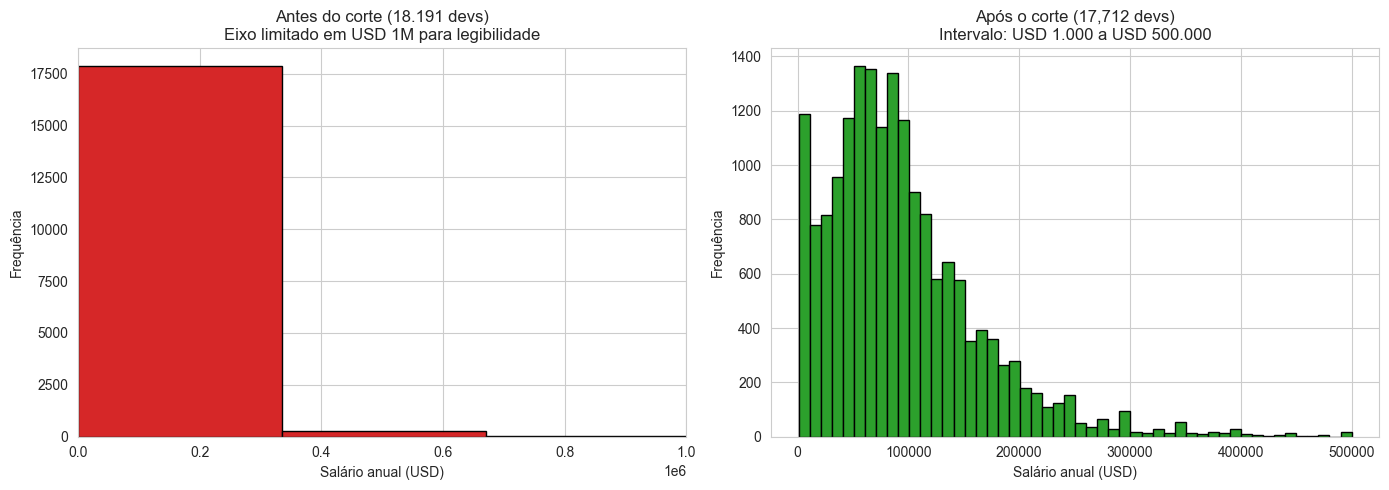

In [8]:
# Recarrega original apenas para o gráfico comparativo
df_original = pd.read_csv(PASTA_DADOS / "df_filtrado_inspecao.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes: limita eixo X em 1M para o gráfico ser legível (extremo é 33M)
axes[0].hist(df_original['ConvertedCompYearly'], bins=100, color='#d62728', edgecolor='black')
axes[0].set_xlim(0, 1_000_000)
axes[0].set_title('Antes do corte (18.191 devs)\nEixo limitado em USD 1M para legibilidade')
axes[0].set_xlabel('Salário anual (USD)')
axes[0].set_ylabel('Frequência')

# Depois
axes[1].hist(df['ConvertedCompYearly'], bins=50, color='#2ca02c', edgecolor='black')
axes[1].set_title(f'Após o corte ({len(df):,} devs)\nIntervalo: USD 1.000 a USD 500.000')
axes[1].set_xlabel('Salário anual (USD)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "02_salario_antes_vs_depois.png", dpi=100, bbox_inches='tight')
plt.show()

del df_original  # libera memória

In [9]:
# Coluna auxiliar para o modelo de robustez
df['log_salario'] = np.log(df['ConvertedCompYearly'])

print(f"Coluna log_salario criada.")
print(f"\nEstatísticas:")
print(df['log_salario'].describe())

Coluna log_salario criada.

Estatísticas:
count    17712.000000
mean        11.109907
std          0.998047
min          6.907755
25%         10.747122
50%         11.304794
75%         11.740332
max         13.122363
Name: log_salario, dtype: float64


## 6. Redução de cardinalidade de Country

153 países → top 10 + "Outros". Mantém países com maior volume de respostas e agrupa o resto.

In [10]:
# Identifica top 10 países por frequência
top10_paises = df['Country'].value_counts().head(10).index.tolist()

print("Top 10 países:")
for i, pais in enumerate(top10_paises, 1):
    n = (df['Country'] == pais).sum()
    print(f"  {i:2}. {pais}: {n:,} ({n/len(df)*100:.1f}%)")

# Cria coluna agrupada
df['Country_agrupado'] = df['Country'].where(df['Country'].isin(top10_paises), 'Outros')
# Abrevia nomes longos para gráficos
df['Country_agrupado'] = df['Country_agrupado'].replace({
    'United States of America': 'USA',
    'United Kingdom of Great Britain and Northern Ireland': 'UK',
})
print(f"\nDistribuição após agrupamento:")
print(df['Country_agrupado'].value_counts())

Top 10 países:
   1. United States of America: 3,919 (22.1%)
   2. Germany: 1,583 (8.9%)
   3. United Kingdom of Great Britain and Northern Ireland: 1,153 (6.5%)
   4. France: 775 (4.4%)
   5. India: 770 (4.3%)
   6. Canada: 708 (4.0%)
   7. Ukraine: 479 (2.7%)
   8. Poland: 462 (2.6%)
   9. Netherlands: 461 (2.6%)
  10. Brazil: 450 (2.5%)

Distribuição após agrupamento:
Country_agrupado
Outros         6952
USA            3919
Germany        1583
UK             1153
France          775
India           770
Canada          708
Ukraine         479
Poland          462
Netherlands     461
Brazil          450
Name: count, dtype: int64


## 7. Agrupamento de DevType em macro-categorias

32 valores → 6 macro-categorias (backend, frontend, fullstack, mobile, data_ml, outros). Necessário para as análises segmentadas do notebook 05.

In [11]:
# Primeiro, ver todos os valores para mapear corretamente
print(df['DevType'].value_counts())

DevType
Developer, full-stack                            6467
Developer, back-end                              3413
Architect, software or solutions                 1235
Developer, desktop or enterprise applications     980
Developer, front-end                              917
Developer, embedded applications or devices       657
Developer, mobile                                 626
Engineering manager                               457
DevOps engineer or professional                   449
Data engineer                                     385
Other (please specify):                           282
AI/ML engineer                                    268
Data scientist                                    202
Cloud infrastructure engineer                     176
Senior executive (C-suite, VP, etc.)              174
Developer, game or graphics                       165
Academic researcher                               132
Founder, technology or otherwise                  119
Developer, QA or tes

In [12]:
# Mapeamento para macro-categorias
mapa_devtype = {
    # Backend
    'Developer, back-end': 'backend',
    'Developer, embedded applications or devices': 'backend',
    'Developer, desktop or enterprise applications': 'backend',

    # Frontend
    'Developer, front-end': 'frontend',

    # Fullstack
    'Developer, full-stack': 'fullstack',

    # Mobile
    'Developer, mobile': 'mobile',

    # Data/ML
    'Data engineer': 'data_ml',
    'Data scientist': 'data_ml',
    'AI/ML engineer': 'data_ml',
    'Data or business analyst': 'data_ml',
    'Applied scientist': 'data_ml',
    'Developer, AI apps or physical AI': 'data_ml',
    'Database administrator or engineer': 'data_ml',
}

# Tudo que não está no mapa vira "outros"
df['DevType_agrupado'] = df['DevType'].map(mapa_devtype).fillna('outros')

print(df['DevType_agrupado'].value_counts())
print(f"\nTotal: {len(df):,}")

DevType_agrupado
fullstack    6467
backend      5050
outros       3541
data_ml      1111
frontend      917
mobile        626
Name: count, dtype: int64

Total: 17,712


## 8. Padronização de EdLevel

Encurta rótulos longos para facilitar gráficos e tabelas.

In [13]:
mapa_edlevel = {
    'Primary/elementary school': 'Fundamental',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'Médio',
    'Some college/university study without earning a degree': 'Superior incompleto',
    'Associate degree (A.A., A.S., etc.)': 'Tecnólogo',
    'Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)': 'Bacharelado',
    'Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)': 'Mestrado',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'Doutorado',
    'Something else': 'Outros',
}

df['EdLevel_agrupado'] = df['EdLevel'].map(mapa_edlevel).fillna('Outros')

print(df['EdLevel_agrupado'].value_counts())

EdLevel_agrupado
Bacharelado            8097
Mestrado               5236
Superior incompleto    2039
Doutorado               780
Médio                   760
Tecnólogo               589
Outros                  139
Fundamental              72
Name: count, dtype: int64


## 9. Dummies das top 20 linguagens

Cria colunas binárias (1/0) para cada linguagem, baseadas em `LanguageHaveWorkedWith` (multirresposta separada por `;`).

In [14]:
# Gera matriz de dummies (uma coluna por linguagem)
dummies_linguagens = df['LanguageHaveWorkedWith'].str.get_dummies(sep=';')

# Seleciona as top 20 por frequência
top20_linguagens = dummies_linguagens.sum().sort_values(ascending=False).head(20).index.tolist()

print("Top 20 linguagens:")
for i, lang in enumerate(top20_linguagens, 1):
    n = dummies_linguagens[lang].sum()
    print(f"  {i:2}. {lang}: {n:,} ({n/len(df)*100:.1f}%)")

# Renomeia colunas com caracteres problemáticos para o statsmodels
mapa_nomes = {
    'C#': 'CSharp',
    'C++': 'CPlusPlus',
    'HTML/CSS': 'HTML_CSS',
    'Bash/Shell (all shells)': 'Bash_Shell',
}

# Seleciona apenas top 20 e renomeia
dummies_top20 = dummies_linguagens[top20_linguagens].rename(columns=mapa_nomes)

# Prefixo "lang_" para identificar facilmente no modelo
dummies_top20 = dummies_top20.add_prefix('lang_')

# Concatena ao df principal
df = pd.concat([df, dummies_top20], axis=1)

print(f"Colunas de linguagem criadas: {len(dummies_top20.columns)}")
print(f"Nomes: {dummies_top20.columns.tolist()}")
print(f"\nShape final do df: {df.shape}")

Top 20 linguagens:
   1. JavaScript: 12,265 (69.2%)
   2. HTML/CSS: 11,228 (63.4%)
   3. SQL: 11,113 (62.7%)
   4. Python: 9,684 (54.7%)
   5. TypeScript: 8,974 (50.7%)
   6. Bash/Shell (all shells): 8,855 (50.0%)
   7. C#: 5,444 (30.7%)
   8. Java: 5,050 (28.5%)
   9. PowerShell: 4,229 (23.9%)
  10. C++: 3,494 (19.7%)
  11. PHP: 3,223 (18.2%)
  12. Go: 3,113 (17.6%)
  13. C: 2,950 (16.7%)
  14. Rust: 2,472 (14.0%)
  15. Kotlin: 2,023 (11.4%)
  16. Lua: 1,442 (8.1%)
  17. Ruby: 1,286 (7.3%)
  18. Swift: 996 (5.6%)
  19. Dart: 976 (5.5%)
  20. Groovy: 965 (5.4%)
Colunas de linguagem criadas: 20
Nomes: ['lang_JavaScript', 'lang_HTML_CSS', 'lang_SQL', 'lang_Python', 'lang_TypeScript', 'lang_Bash_Shell', 'lang_CSharp', 'lang_Java', 'lang_PowerShell', 'lang_CPlusPlus', 'lang_PHP', 'lang_Go', 'lang_C', 'lang_Rust', 'lang_Kotlin', 'lang_Lua', 'lang_Ruby', 'lang_Swift', 'lang_Dart', 'lang_Groovy']

Shape final do df: (17712, 33)


## 10. Salvamento do dataset limpo

Salva `df_limpo.csv` em `data/processed/` para uso nos próximos notebooks.

In [15]:
caminho_saida = PASTA_DADOS / "df_limpo.csv"
df.to_csv(caminho_saida, index=False)

print(f"Dataset salvo em: {caminho_saida}")
print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"\nColunas finais:")
print(df.columns.tolist())

Dataset salvo em: ..\data\processed\df_limpo.csv
Linhas: 17,712
Colunas: 33

Colunas finais:
['ResponseId', 'MainBranch', 'EdLevel', 'Employment', 'YearsCode', 'DevType', 'Country', 'LanguageHaveWorkedWith', 'ConvertedCompYearly', 'log_salario', 'Country_agrupado', 'DevType_agrupado', 'EdLevel_agrupado', 'lang_JavaScript', 'lang_HTML_CSS', 'lang_SQL', 'lang_Python', 'lang_TypeScript', 'lang_Bash_Shell', 'lang_CSharp', 'lang_Java', 'lang_PowerShell', 'lang_CPlusPlus', 'lang_PHP', 'lang_Go', 'lang_C', 'lang_Rust', 'lang_Kotlin', 'lang_Lua', 'lang_Ruby', 'lang_Swift', 'lang_Dart', 'lang_Groovy']


## Conclusões

A etapa de limpeza resultou em um dataset com 17.712 observações e 33 variáveis, pronto para a análise exploratória e modelagem.

**Tratamentos aplicados:**
- Imputação de 45 valores ausentes de tempo de experiência pela mediana (15 anos) e limitação superior em 50 anos (39 observações ajustadas).
- Remoção de outliers salariais fora do intervalo USD 1.000 a USD 500.000 (479 observações, 2,63% da amostra).
- Criação da variável auxiliar em escala logarítmica (`log_salario`) para uso em modelo de robustez.
- Redução de cardinalidade: 153 países agrupados em top 10 + "Outros"; 32 categorias de atuação consolidadas em 6 macro-categorias (backend, frontend, fullstack, mobile, data_ml, outros).
- Padronização dos rótulos de escolaridade para versões curtas em português.
- Codificação binária das 20 linguagens mais frequentes na amostra.

O conjunto resultante preserva 97,37% da amostra filtrada original (17.712 de 18.191), mantendo representatividade suficiente para as análises segmentadas previstas.